In [ ]:
!pip install torch-geometric rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 53.0 MB/s eta 0:00:00


# Import biblioteka

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import from_smiles

from rdkit import Chem
from rdkit.Chem import Draw
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, roc_curve

# Evaluacija modela - ESOL i Tox21

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=128, num_tasks=1):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim)

        self.dropout = torch.nn.Dropout(0.2)

        self.lin1 = torch.nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin2 = torch.nn.Linear(hidden_dim // 2, num_tasks)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)

        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        x = global_mean_pool(x, batch)

        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        x = self.lin2(x)

        return x

esol_model = GCN(num_features=9, hidden_dim=128, num_tasks=1)
esol_model.load_state_dict(torch.load('gcn_esol.pt'))
esol_model.eval()

tox_model = GCN(num_features=9, hidden_dim=128, num_tasks=12)
tox_model.load_state_dict(torch.load('gcn_tox21.pt'))
tox_model.eval()

print("Oba modela uspješno učitana!")

Oba modela uspješno učitana!


## ESOL — evaluacija na test setu

In [ ]:
torch.manual_seed(22)
np.random.seed(22)

esol_dataset = MoleculeNet(root='data/', name='ESOL').shuffle()

train_size = int(len(esol_dataset) * 0.8)
val_size = int(len(esol_dataset) * 0.1)

esol_test = esol_dataset[train_size + val_size:]
esol_test_loader = DataLoader(esol_test, batch_size=32)

all_preds = []
all_targets = []
all_smiles = []

with torch.no_grad():
    for batch in esol_test_loader:
        pred = esol_model(batch).squeeze()
        all_preds.extend(pred.numpy().tolist())
        all_targets.extend(batch.y.squeeze().numpy().tolist())
        all_smiles.extend(batch.smiles)

preds = np.array(all_preds)
targets = np.array(all_targets)

rmse = np.sqrt(mean_squared_error(targets, preds))
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)

print(f"ESOL Test rezultati ({len(esol_test)} molekula):")
print(f"  RMSE: {rmse:.4f} log mol/L")
print(f"  MAE:  {mae:.4f} log mol/L")
print(f"  R²:   {r2:.4f}")

Processing...


ESOL Test rezultati (114 molekula):
  RMSE: 0.6055 log mol/L
  MAE:  0.4399 log mol/L
  R²:   0.9229


Done!


## ESOL - scatter plot prekcija vs stvarnost

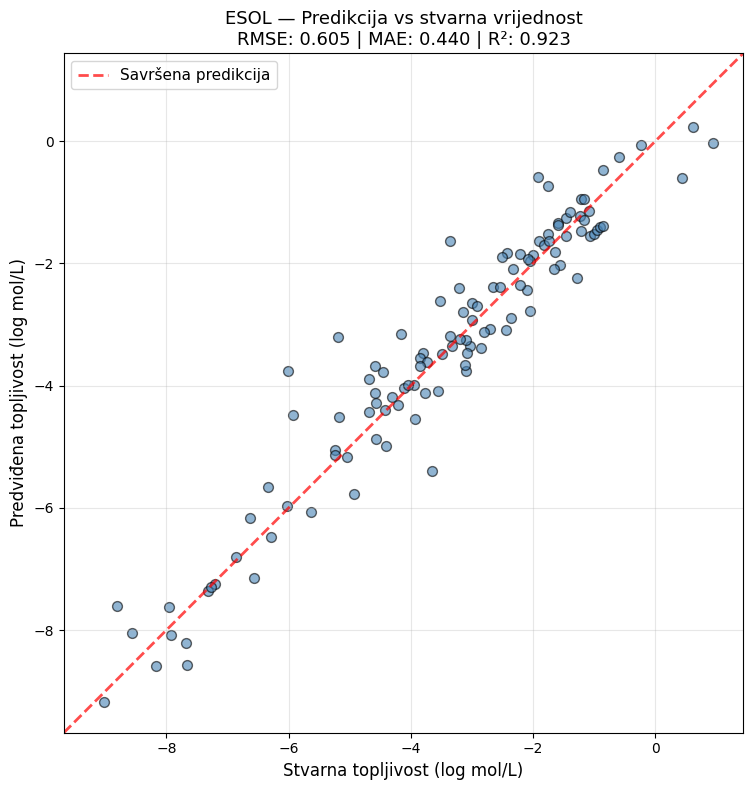

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(targets, preds, alpha=0.6, color='steelblue', edgecolor='black', s=50)

lims = [min(targets.min(), preds.min()) - 0.5, max(targets.max(), preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', alpha=0.7, linewidth=2, label='Savršena predikcija')

ax.set_xlabel('Stvarna topljivost (log mol/L)', fontsize=12)
ax.set_ylabel('Predviđena topljivost (log mol/L)', fontsize=12)
ax.set_title(f'ESOL — Predikcija vs stvarna vrijednost\nRMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}', fontsize=13)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## ESOL - analiza najvećih grešaka

In [ ]:
errors = np.abs(preds - targets)
error_df = pd.DataFrame({
    'SMILES': all_smiles,
    'Stvarno': targets,
    'Predviđeno': preds,
    'Greška': errors,
})

worst_5 = error_df.sort_values('Greška', ascending=False).head(5).reset_index(drop=True)
print("5 molekula s najvećom greškom predikcije:\n")
print(worst_5[['Stvarno', 'Predviđeno', 'Greška']].to_string(index=False))

5 molekula s najvećom greškom predikcije:

 Stvarno  Predviđeno   Greška
  -6.005   -3.767864 2.237136
  -5.190   -3.207409 1.982591
  -3.658   -5.398831 1.740831
  -3.364   -1.631243 1.732757
  -5.931   -4.483757 1.447244


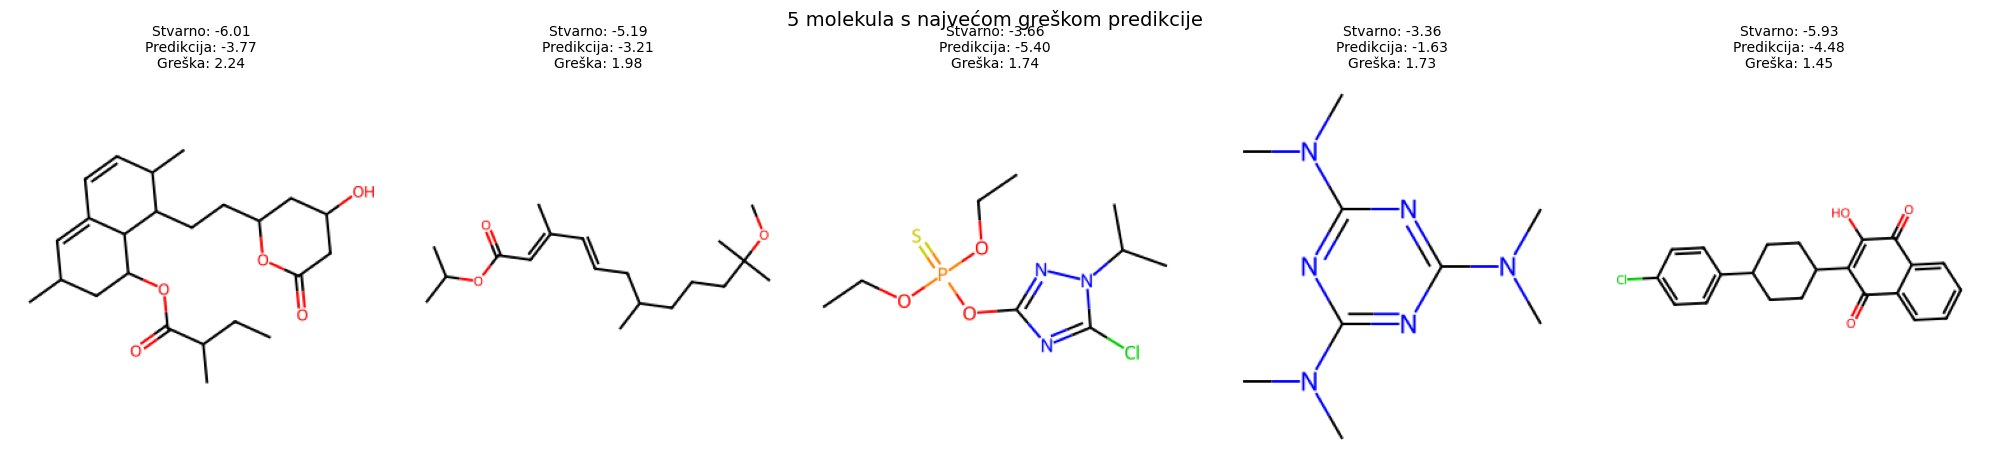

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (_, row) in zip(axes, worst_5.iterrows()):
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        img = Draw.MolToImage(mol, size=(300, 300))
        ax.imshow(img)
    ax.set_title(f"Stvarno: {row['Stvarno']:.2f}\nPredikcija: {row['Predviđeno']:.2f}\nGreška: {row['Greška']:.2f}", fontsize=10)
    ax.axis('off')

plt.suptitle('5 molekula s najvećom greškom predikcije', fontsize=14)
plt.tight_layout()
plt.show()

## Tox21 — evaluacija i AUC-ROC po tasku

In [ ]:
torch.manual_seed(1)
np.random.seed(1)

tox21_dataset = MoleculeNet(root='data/', name='Tox21').shuffle()

tox_train_size = int(len(tox21_dataset) * 0.8)
tox_val_size = int(len(tox21_dataset) * 0.1)

tox_test = tox21_dataset[tox_train_size + tox_val_size:]
tox_test_loader = DataLoader(tox_test, batch_size=64)

Extracting data/tox21/raw/tox21.csv.gz
Processing...
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'O=CO[AlH3](OC=O)OC=O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'CC(=O)O[AlH3](O)O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'CC(=O)O[AlH3](O)OC(C)=O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC' since it resulted in zero atoms
  self.process()
/usr/local/lib/pyt

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tox_test_loader:
        pred = torch.sigmoid(tox_model(batch))
        y = batch.y.view(pred.shape)
        all_preds.append(pred.numpy())
        all_labels.append(y.numpy())

preds = np.concatenate(all_preds)
labels = np.concatenate(all_labels)

In [ ]:
task_names = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
              'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

aucs = []
for i, name in enumerate(task_names):
    mask = ~np.isnan(labels[:, i])
    if len(np.unique(labels[mask, i])) == 2:
        auc = roc_auc_score(labels[mask, i], preds[mask, i])
        aucs.append((name, auc))

aucs_df = pd.DataFrame(aucs, columns=['Task', 'AUC-ROC'])
aucs_df = aucs_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
aucs_df['AUC-ROC'] = aucs_df['AUC-ROC'].round(4)

print(f"Prosjecni AUC-ROC: {aucs_df['AUC-ROC'].mean():.4f}")
print(f"Najbolji task: {aucs_df.iloc[0]['Task']} (AUC {aucs_df.iloc[0]['AUC-ROC']})")
print(f"Najlosiji task: {aucs_df.iloc[-1]['Task']} (AUC {aucs_df.iloc[-1]['AUC-ROC']})")
print()
aucs_df

Prosjecni AUC-ROC: 0.8908
Najbolji task: NR-AR-LBD (AUC 0.9495)
Najlosiji task: NR-ER (AUC 0.7671)



,Task,AUC-ROC
0,NR-AR-LBD,0.9495
1,SR-MMP,0.9443
2,NR-PPAR-gamma,0.9396
3,SR-ATAD5,0.9384
4,NR-AhR,0.9329
5,NR-Aromatase,0.8926
6,SR-HSE,0.8917
7,SR-p53,0.8711
8,NR-ER-LBD,0.8677
9,NR-AR,0.8590


## ROC krivulje za top 3 taska

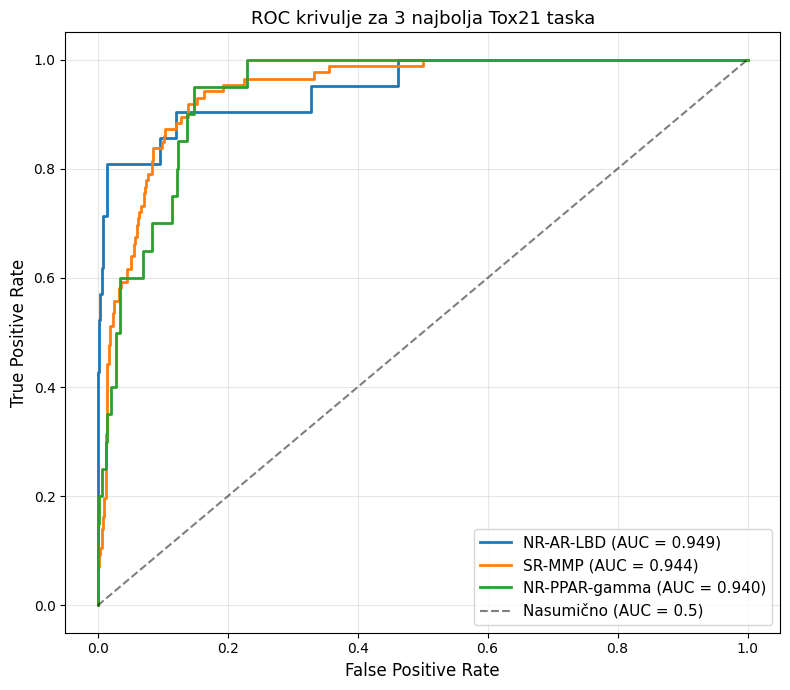

In [ ]:
top3_tasks = aucs_df.head(3)['Task'].tolist()

fig, ax = plt.subplots(figsize=(8, 7))

for task_name in top3_tasks:
    idx = task_names.index(task_name)
    mask = ~np.isnan(labels[:, idx])
    fpr, tpr, _ = roc_curve(labels[mask, idx], preds[mask, idx])
    auc_val = roc_auc_score(labels[mask, idx], preds[mask, idx])
    ax.plot(fpr, tpr, linewidth=2, label=f'{task_name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Nasumično (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC krivulje za 3 najbolja Tox21 taska', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Test predikcije na poznatim molekulama

In [ ]:
def predict_molecule(smiles, esol_model, tox_model):
    graph = from_smiles(smiles)
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long)

    with torch.no_grad():
        solubility = esol_model(graph).item()
        toxicity = torch.sigmoid(tox_model(graph)).squeeze().numpy()

    return solubility, toxicity


poznate_molekule = {
    'Voda':        'O',
    'Etanol':      'CCO',
    'Kofein':      'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Aspirin':     'CC(=O)OC1=CC=CC=C1C(=O)O',
    'Glukoza':     'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',
    'Paracetamol': 'CC(=O)NC1=CC=C(O)C=C1',
    'Nikotin':     'CN1CCCC1c1cccnc1',
    'Heksan':      'CCCCCC',
}

In [ ]:
rezultati = []
for ime, smiles in poznate_molekule.items():
    sol, tox = predict_molecule(smiles, esol_model, tox_model)
    avg_toxicity = tox.mean()
    max_toxicity = tox.max()
    num_high_risk = (tox > 0.5).sum()

    rezultati.append({
        'Molekula': ime,
        'Topljivost (log mol/L)': f'{sol:.2f}',
        'Prosj. rizik toks.': f'{avg_toxicity:.3f}',
        'Max rizik': f'{max_toxicity:.3f}',
        'Taskova > 0.5': int(num_high_risk),
    })

rez_df = pd.DataFrame(rezultati)
rez_df

,Molekula,Topljivost (log mol/L),Prosj. rizik toks.,Max rizik,Taskova > 0.5
0,Voda,0.60,0.000,0.000,0
1,Etanol,0.99,0.002,0.013,0
2,Kofein,-1.58,0.009,0.030,0
3,Aspirin,-2.19,0.019,0.072,0
4,Glukoza,0.72,0.021,0.147,0
5,Paracetamol,-1.54,0.158,0.455,0
6,Nikotin,-1.20,0.007,0.039,0
7,Heksan,-3.56,0.007,0.051,0
